# Project 3 — Reorder Point Classification Engine

**Main question:** When should we replenish inventory?

**System flow:** `Forecast Accuracy → Safety Stock → [Project 3] → Fill Rate → Monetization → ROI`

---

## Sections
1. Load data and Project 2 safety stock results
2. Calculate reorder points
3. Compare recommended vs current ROP
4. Classify replenishment policy (continuous vs periodic review)
5. Stock cover and lead-time exposure analysis
6. Inventory policy matrix
7. Business summary and recommendations

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.inventory import reorder_point, days_on_hand, eoq

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)

# Use processed (real) data if available, else fall back to sample (synthetic)
_processed = ROOT / "data" / "processed" / "master_data.csv"
_sample    = ROOT / "data" / "sample"    / "master_data.csv"
DATA = _processed if _processed.exists() else _sample
print(f"Data source: {DATA.relative_to(ROOT)}")
P2   = ROOT / "outputs" / "tables" / "02_safety_stock_results.csv"
OUT  = ROOT / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)

Data source: data\processed\master_data.csv
Root: C:\Users\simba\OneDrive\Dokumenter\Dev\supply-chain-uncertainty-system


---
## 1. Load data and Project 2 safety stock results

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"])
p2 = pd.read_csv(P2)

# Use clean weeks only
df_clean = df[(df["promo_flag"] == 0) & (df["holiday_flag"] == 0)].copy()

# Aggregate master stats per SKU-location
master = (
    df_clean
    .groupby(["sku", "location"])
    .agg(
        avg_weekly_demand=("actual_demand", "mean"),
        std_weekly_demand=("actual_demand", "std"),
        lead_time_mean=("lead_time_mean", "first"),
        lead_time_std=("lead_time_std", "first"),
        unit_cost=("unit_cost", "first"),
        unit_margin=("unit_margin", "first"),
        holding_cost_rate=("holding_cost_rate", "first"),
        service_target=("service_target", "first"),
        current_rop=("reorder_point", "first"),
        current_ss=("safety_stock", "first"),
        abc_class=("abc_class", "first"),
        xyz_class=("xyz_class", "first"),
    )
    .reset_index()
)

# Merge recommended SS from Project 2
master = master.merge(
    p2[["sku", "location", "rec_ss", "ss_status"]],
    on=["sku", "location"],
)

master["segment"] = master["abc_class"] + "/" + master["xyz_class"]
print(f"{len(master)} SKU-locations loaded")
master.head(3)

300 SKU-locations loaded


,sku,location,avg_weekly_demand,std_weekly_demand,lead_time_mean,lead_time_std,unit_cost,unit_margin,holding_cost_rate,service_target,current_rop,current_ss,abc_class,xyz_class,rec_ss,ss_status,segment
0,SKU_A01,Store_Central,259.62,50.69,5,1,1.25,0.38,0.20,0.95,301.00,111.00,A,X,93.00,Over-buffered,A/X
1,SKU_A01,Store_East,156.00,28.95,10,2,1.25,0.38,0.20,0.95,326.00,99.00,A,X,93.00,On target,A/X
2,SKU_A01,Store_North,229.21,40.32,7,1,1.25,0.38,0.20,0.95,355.00,115.00,A,X,85.00,Over-buffered,A/X


---
## 2. Calculate reorder points

$$ROP = \bar{d} \times LT + SS$$

Where demand and lead time are in the **same time unit** (weeks here).

In [3]:
LT_PER_WEEK = 7.0

master["lt_weeks"]     = master["lead_time_mean"] / LT_PER_WEEK
master["lt_std_weeks"] = master["lead_time_std"]  / LT_PER_WEEK

# Lead-time demand = avg weekly demand * lead time in weeks
master["ltd_avg"] = master["avg_weekly_demand"] * master["lt_weeks"]

# Recommended ROP using Project 2 safety stock
master["rec_rop"] = (
    master["avg_weekly_demand"] * master["lt_weeks"] + master["rec_ss"]
).round(0)

# Current ROP delta
master["rop_delta"]     = master["rec_rop"] - master["current_rop"]
master["rop_delta_pct"] = master["rop_delta"] / master["current_rop"]

def rop_status(delta: float) -> str:
    if delta > 5:
        return "Too low — replenish earlier"
    elif delta < -5:
        return "Too high — replenish later"
    return "On target"

master["rop_status"] = master["rop_delta"].apply(rop_status)

print("ROP status:")
print(master["rop_status"].value_counts())
print()
print(master[["sku", "location", "abc_class", "ltd_avg", "rec_ss", "current_rop", "rec_rop", "rop_delta", "rop_status"]].head(8).to_string(index=False))

ROP status:
rop_status
On target                     205
Too high — replenish later     95
Name: count, dtype: int64

    sku      location abc_class  ltd_avg  rec_ss  current_rop  rec_rop  rop_delta                 rop_status
SKU_A01 Store_Central         A   185.44   93.00       301.00   278.00     -23.00 Too high — replenish later
SKU_A01    Store_East         A   222.86   93.00       326.00   316.00     -10.00 Too high — replenish later
SKU_A01   Store_North         A   229.21   85.00       355.00   314.00     -41.00 Too high — replenish later
SKU_A01   Store_South         A   182.40   68.00       259.00   250.00      -9.00 Too high — replenish later
SKU_A01    Store_West         A   249.74  106.00       376.00   356.00     -20.00 Too high — replenish later
SKU_A02 Store_Central         A   158.47   84.00       258.00   242.00     -16.00 Too high — replenish later
SKU_A02    Store_East         A   191.50   82.00       285.00   273.00     -12.00 Too high — replenish later
SKU_A02   

---
## 3. Compare recommended vs current ROP

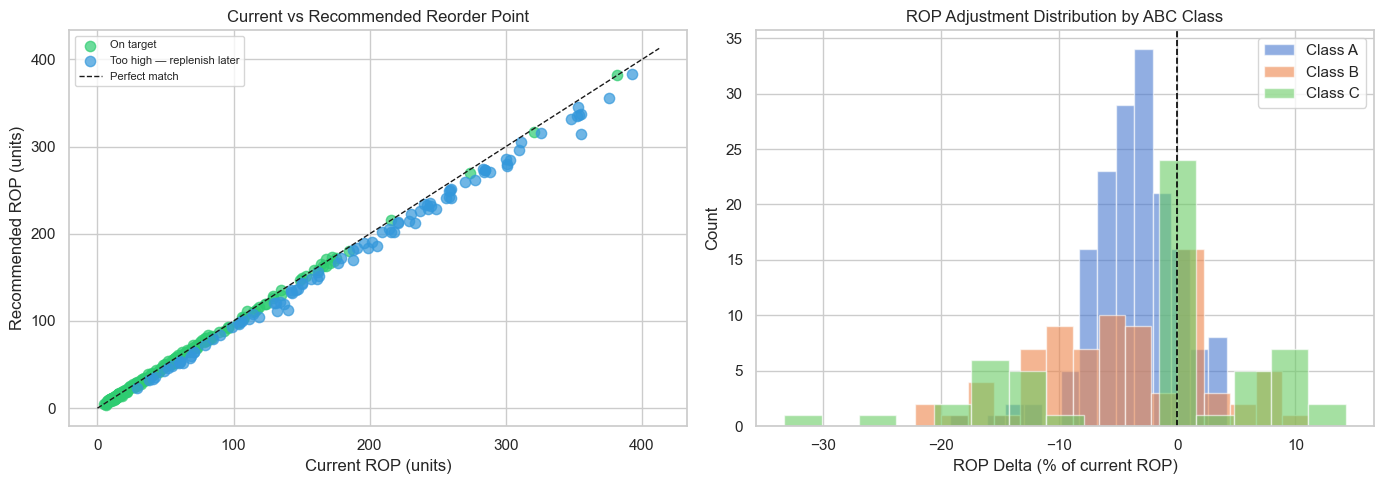

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: current vs recommended ROP
color_map = {
    "Too low — replenish earlier": "#e74c3c",
    "Too high — replenish later":  "#3498db",
    "On target":                   "#2ecc71",
}
for status, grp in master.groupby("rop_status"):
    axes[0].scatter(
        grp["current_rop"], grp["rec_rop"],
        label=status, color=color_map[status], alpha=0.7, s=55,
    )
lim = max(master[["current_rop", "rec_rop"]].max()) * 1.05
axes[0].plot([0, lim], [0, lim], "k--", linewidth=1, label="Perfect match")
axes[0].set_xlabel("Current ROP (units)")
axes[0].set_ylabel("Recommended ROP (units)")
axes[0].set_title("Current vs Recommended Reorder Point")
axes[0].legend(fontsize=8)

# ROP delta distribution by ABC class
for abc, grp in master.groupby("abc_class"):
    axes[1].hist(grp["rop_delta_pct"] * 100, bins=15, alpha=0.6, label=f"Class {abc}")
axes[1].axvline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("ROP Delta (% of current ROP)")
axes[1].set_ylabel("Count")
axes[1].set_title("ROP Adjustment Distribution by ABC Class")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "03a_rop_comparison.png", dpi=150)
plt.show()

---
## 4. Classify replenishment policy

Two main review types:
- **Continuous review (s, Q):** order fixed quantity Q whenever inventory falls to ROP
- **Periodic review (R, S):** review every R periods, order up to max level S

Rule of thumb:
- A/X: continuous review (high value, predictable — watch closely)
- B/Y: either, but lean continuous
- C/Z: periodic review (low value, lumpy — not worth watching daily)

In [5]:
POLICY_MAP = {
    "A/X": "Continuous (s,Q)",
    "A/Y": "Continuous (s,Q)",
    "A/Z": "Continuous (s,Q)",
    "B/X": "Continuous (s,Q)",
    "B/Y": "Continuous (s,Q)",
    "B/Z": "Periodic (R,S)",
    "C/X": "Periodic (R,S)",
    "C/Y": "Periodic (R,S)",
    "C/Z": "Periodic (R,S)",
}
master["review_policy"] = master["segment"].map(POLICY_MAP).fillna("Periodic (R,S)")

# EOQ — economic order quantity
WEEKS_PER_YEAR = 52
ORDERING_COST  = 150  # CHF per order (flat assumption)

master["annual_demand"] = master["avg_weekly_demand"] * WEEKS_PER_YEAR
master["holding_cost_pu"] = master["unit_cost"] * master["holding_cost_rate"]
master["eoq"] = master.apply(
    lambda r: eoq(r["annual_demand"], ORDERING_COST, r["holding_cost_pu"]),
    axis=1,
).round(0)

# For periodic review: suggest review period in weeks
master["review_period_weeks"] = master.apply(
    lambda r: round(r["eoq"] / r["avg_weekly_demand"], 1)
    if r["avg_weekly_demand"] > 0 else 4,
    axis=1,
)

print("Policy assignment:")
print(master.groupby(["segment", "review_policy"]).size().to_string())
print()
print(master[["sku", "location", "segment", "review_policy", "eoq", "review_period_weeks"]].head(8).to_string(index=False))

Policy assignment:
segment  review_policy   
A/X      Continuous (s,Q)    95
A/Y      Continuous (s,Q)    65
A/Z      Continuous (s,Q)     5
B/Y      Continuous (s,Q)    40
B/Z      Periodic (R,S)      40
C/Y      Periodic (R,S)       5
C/Z      Periodic (R,S)      50

    sku      location segment    review_policy     eoq  review_period_weeks
SKU_A01 Store_Central     A/X Continuous (s,Q) 4025.00                15.50
SKU_A01    Store_East     A/X Continuous (s,Q) 3120.00                20.00
SKU_A01   Store_North     A/X Continuous (s,Q) 3782.00                16.50
SKU_A01   Store_South     A/X Continuous (s,Q) 3374.00                18.50
SKU_A01    Store_West     A/X Continuous (s,Q) 2791.00                22.40
SKU_A02 Store_Central     A/X Continuous (s,Q) 3516.00                15.80
SKU_A02    Store_East     A/X Continuous (s,Q) 2733.00                20.40
SKU_A02   Store_North     A/X Continuous (s,Q) 3311.00                16.80


---
## 5. Stock cover and lead-time exposure analysis

In [6]:
# Average on-hand and on-order from master data
pos = (
    df_clean
    .groupby(["sku", "location"])
    .agg(
        avg_on_hand=("on_hand", "mean"),
        avg_on_order=("on_order", "mean"),
        stockout_rate=("stockout_flag", "mean"),
    )
    .reset_index()
)
master = master.merge(pos, on=["sku", "location"])

# Stock cover = on-hand / avg weekly demand (in weeks)
master["stock_cover_weeks"] = (
    master["avg_on_hand"] / master["avg_weekly_demand"]
).replace([np.inf, -np.inf], np.nan).round(1)

# Lead-time cover = how many weeks of cover exist relative to lead time
master["lt_cover_ratio"] = (
    master["stock_cover_weeks"] / master["lt_weeks"]
).round(2)

print("Stockout rate by segment:")
print(
    master.groupby("segment")["stockout_rate"]
    .mean()
    .mul(100)
    .round(1)
    .rename("stockout_rate_%")
    .to_string()
)
print()
print("Avg stock cover (weeks) by segment:")
print(master.groupby("segment")["stock_cover_weeks"].mean().round(1).to_string())

Stockout rate by segment:
segment
A/X   53.30
A/Y   19.20
A/Z    7.80
B/Y   23.60
B/Z    9.90
C/Y   19.50
C/Z   12.80

Avg stock cover (weeks) by segment:
segment
A/X   1.00
A/Y   1.80
A/Z   2.90
B/Y   1.60
B/Z   2.70
C/Y   1.70
C/Z   2.50


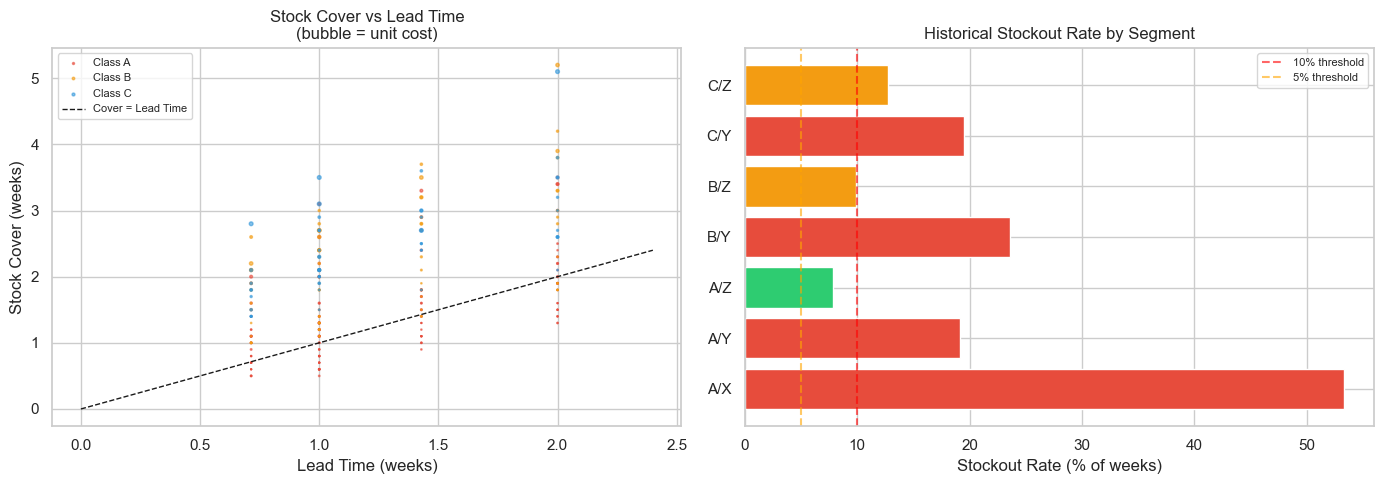

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stock cover vs lead time — bubble chart
abc_colors = {"A": "#e74c3c", "B": "#f39c12", "C": "#3498db"}
for abc, grp in master.groupby("abc_class"):
    axes[0].scatter(
        grp["lt_weeks"],
        grp["stock_cover_weeks"],
        s=grp["unit_cost"] / 3,
        color=abc_colors[abc],
        alpha=0.6,
        label=f"Class {abc}",
    )
# 1:1 line = stock cover equals lead time (bare minimum)
lim = master["lt_weeks"].max() * 1.2
axes[0].plot([0, lim], [0, lim], "k--", linewidth=1, label="Cover = Lead Time")
axes[0].set_xlabel("Lead Time (weeks)")
axes[0].set_ylabel("Stock Cover (weeks)")
axes[0].set_title("Stock Cover vs Lead Time\n(bubble = unit cost)")
axes[0].legend(fontsize=8)

# Stockout rate by segment
so_rate = master.groupby("segment")["stockout_rate"].mean() * 100
colors  = ["#e74c3c" if v > 15 else "#f39c12" if v > 8 else "#2ecc71" for v in so_rate]
axes[1].barh(so_rate.index, so_rate.values, color=colors)
axes[1].axvline(10, color="red",    linestyle="--", alpha=0.6, label="10% threshold")
axes[1].axvline(5,  color="orange", linestyle="--", alpha=0.6, label="5% threshold")
axes[1].set_xlabel("Stockout Rate (% of weeks)")
axes[1].set_title("Historical Stockout Rate by Segment")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "03b_stock_cover.png", dpi=150)
plt.show()

---
## 6. Inventory policy matrix

Full policy per SKU-location: ROP, order quantity (EOQ), review type, and max level for periodic review.

In [8]:
# Max level for periodic review: S = ROP + EOQ
master["max_level"] = (master["rec_rop"] + master["eoq"]).round(0)

# Replenishment frequency (orders per year)
master["orders_per_year"] = (
    master["annual_demand"] / master["eoq"]
).replace([np.inf, -np.inf], np.nan).round(1)

# Policy summary by segment
policy_summary = (
    master.groupby("segment")
    .agg(
        n=("sku", "count"),
        review_policy=("review_policy", "first"),
        avg_rop=("rec_rop", "mean"),
        avg_eoq=("eoq", "mean"),
        avg_max_level=("max_level", "mean"),
        avg_review_weeks=("review_period_weeks", "mean"),
        avg_orders_yr=("orders_per_year", "mean"),
        avg_stockout_pct=("stockout_rate", lambda x: x.mean() * 100),
    )
    .round(1)
)
policy_summary

,n,review_policy,avg_rop,avg_eoq,avg_max_level,avg_review_weeks,avg_orders_yr,avg_stockout_pct
segment,,,,,,,,
A/X,95,"Continuous (s,Q)",200.80,2379.10,2579.90,20.20,2.70,53.30
A/Y,65,"Continuous (s,Q)",82.60,945.10,1027.70,24.00,2.20,19.20
A/Z,5,"Continuous (s,Q)",30.20,265.60,295.80,25.00,2.10,7.80
B/Y,40,"Continuous (s,Q)",55.60,884.80,940.40,32.40,1.60,23.60
B/Z,40,"Periodic (R,S)",21.00,273.70,294.80,34.70,1.50,9.90
C/Y,5,"Periodic (R,S)",20.00,429.80,449.80,48.10,1.10,19.50
C/Z,50,"Periodic (R,S)",10.90,214.70,225.70,49.20,1.10,12.80


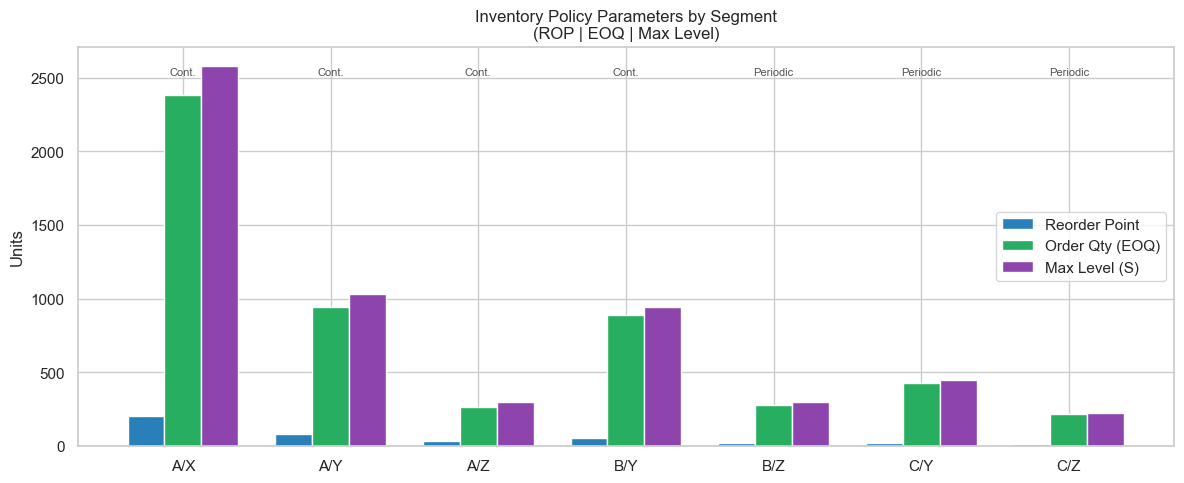

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

segments = policy_summary.index.tolist()
x = np.arange(len(segments))
w = 0.25

bars1 = ax.bar(x - w, policy_summary["avg_rop"],       w, label="Reorder Point",  color="#2980b9")
bars2 = ax.bar(x,     policy_summary["avg_eoq"],       w, label="Order Qty (EOQ)", color="#27ae60")
bars3 = ax.bar(x + w, policy_summary["avg_max_level"], w, label="Max Level (S)",   color="#8e44ad")

ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.set_ylabel("Units")
ax.set_title("Inventory Policy Parameters by Segment\n(ROP | EOQ | Max Level)")
ax.legend()

# Annotate policy type
for i, seg in enumerate(segments):
    policy = policy_summary.loc[seg, "review_policy"]
    short  = "Cont." if "Continuous" in policy else "Periodic"
    ax.text(i, ax.get_ylim()[1] * 0.95, short,
            ha="center", va="top", fontsize=8, color="#555")

plt.tight_layout()
plt.savefig(FIG / "03c_policy_matrix.png", dpi=150)
plt.show()

---
## 7. Business summary and recommendations

In [10]:
def recommend(row) -> str:
    if row["rop_status"] == "Too low — replenish earlier" and row["abc_class"] == "A":
        return "Raise ROP urgently — A class stockout risk"
    elif row["rop_status"] == "Too low — replenish earlier":
        return "Raise ROP — replenishment triggered too late"
    elif row["rop_status"] == "Too high — replenish later" and row["abc_class"] == "C":
        return "Lower ROP — excess inventory risk on low-value item"
    elif row["rop_status"] == "Too high — replenish later":
        return "Lower ROP — consider reducing order frequency"
    elif row["stockout_rate"] > 0.15:
        return "High stockout rate — review demand signal and SS"
    return "On target — monitor"

master["recommendation"] = master.apply(recommend, axis=1)

print("Recommendation summary:")
print(master["recommendation"].value_counts().to_string())

Recommendation summary:
recommendation
On target — monitor                                 114
Lower ROP — consider reducing order frequency        95
High stockout rate — review demand signal and SS     91


In [11]:
output_cols = [
    "sku", "location", "abc_class", "xyz_class", "segment",
    "avg_weekly_demand", "lt_weeks", "ltd_avg",
    "rec_ss", "current_rop", "rec_rop", "rop_delta", "rop_status",
    "review_policy", "eoq", "review_period_weeks", "max_level",
    "orders_per_year", "stock_cover_weeks", "stockout_rate",
    "recommendation",
]
output = master[output_cols].sort_values(["abc_class", "rop_delta"], ascending=[True, True])
output.to_csv(OUT / "tables" / "03_reorder_point_results.csv", index=False)
print("Saved results table.")
output.head(12)

Saved results table.


,sku,location,abc_class,xyz_class,segment,avg_weekly_demand,lt_weeks,ltd_avg,rec_ss,current_rop,...,rop_delta,rop_status,review_policy,eoq,review_period_weeks,max_level,orders_per_year,stock_cover_weeks,stockout_rate,recommendation
2,SKU_A01,Store_North,A,X,A/X,229.21,1.00,229.21,85.00,355.00,...,-41.00,Too high — replenish later,"Continuous (s,Q)",3782.00,16.50,4096.00,3.20,0.80,0.75,Lower ROP — consider reducing order frequency
85,SKU_B03,Store_Central,A,Y,A/Y,83.91,0.71,59.94,53.00,140.00,...,-27.00,Too high — replenish later,"Continuous (s,Q)",1618.00,19.30,1731.00,2.70,1.50,0.21,Lower ROP — consider reducing order frequency
0,SKU_A01,Store_Central,A,X,A/X,259.62,0.71,185.44,93.00,301.00,...,-23.00,Too high — replenish later,"Continuous (s,Q)",4025.00,15.50,4303.00,3.40,0.70,0.83,Lower ROP — consider reducing order frequency
20,SKU_A05,Store_Central,A,X,A/X,276.72,0.71,197.65,82.00,301.00,...,-21.00,Too high — replenish later,"Continuous (s,Q)",4430.00,16.00,4710.00,3.20,0.60,0.98,Lower ROP — consider reducing order frequency
52,SKU_A11,Store_North,A,X,A/X,143.68,1.00,143.68,68.00,233.00,...,-21.00,Too high — replenish later,"Continuous (s,Q)",2495.00,17.40,2707.00,3.00,1.00,0.50,Lower ROP — consider reducing order frequency
4,SKU_A01,Store_West,A,X,A/X,124.87,2.00,249.74,106.00,376.00,...,-20.00,Too high — replenish later,"Continuous (s,Q)",2791.00,22.40,3147.00,2.30,1.60,0.17,Lower ROP — consider reducing order frequency
54,SKU_A11,Store_West,A,X,A/X,78.56,2.00,157.13,72.00,249.00,...,-20.00,Too high — replenish later,"Continuous (s,Q)",1845.00,23.50,2074.00,2.20,1.90,0.07,Lower ROP — consider reducing order frequency
93,SKU_B04,Store_South,A,Y,A/Y,61.96,1.00,61.96,50.00,132.00,...,-20.00,Too high — replenish later,"Continuous (s,Q)",1595.00,25.70,1707.00,2.00,1.80,0.14,Lower ROP — consider reducing order frequency
25,SKU_A06,Store_Central,A,X,A/X,239.64,0.71,171.17,70.00,260.00,...,-19.00,Too high — replenish later,"Continuous (s,Q)",4557.00,19.00,4798.00,2.70,0.60,0.98,Lower ROP — consider reducing order frequency
56,SKU_A12,Store_East,A,X,A/X,87.48,1.43,124.97,61.00,205.00,...,-19.00,Too high — replenish later,"Continuous (s,Q)",1761.00,20.10,1947.00,2.60,1.40,0.21,Lower ROP — consider reducing order frequency


In [12]:
print("===== REORDER POINT SUMMARY =====")
print(f"SKU-locations assessed:            {len(master)}")
print(f"ROP too low (replenish earlier):   {(master['rop_status']=='Too low — replenish earlier').sum()}")
print(f"ROP too high (replenish later):    {(master['rop_status']=='Too high — replenish later').sum()}")
print(f"On target:                         {(master['rop_status']=='On target').sum()}")
print()
print(f"Avg stock cover:                   {master['stock_cover_weeks'].mean():.1f} weeks")
print(f"Avg stockout rate (historical):    {master['stockout_rate'].mean()*100:.1f}%")
print(f"Avg orders per year (EOQ-based):   {master['orders_per_year'].mean():.1f}")
print()
print("Continuous review SKUs:  ", (master['review_policy'] == 'Continuous (s,Q)').sum())
print("Periodic review SKUs:    ", (master['review_policy'] == 'Periodic (R,S)').sum())
print()
print("ROP and order quantity feed directly into Project 4 (Fill Rate Simulator).")

===== REORDER POINT SUMMARY =====
SKU-locations assessed:            300
ROP too low (replenish earlier):   0
ROP too high (replenish later):    95
On target:                         205

Avg stock cover:                   1.8 weeks
Avg stockout rate (historical):    28.1%
Avg orders per year (EOQ-based):   2.0

Continuous review SKUs:   205
Periodic review SKUs:     95

ROP and order quantity feed directly into Project 4 (Fill Rate Simulator).
